# 🎯 01_Sample_Space — Interactive Visualization Notebook

## MLVerse-Math Educational Repository

**Author:** MLVerse Contributors  
**Python:** 3.12+ | **Libraries:** NumPy, Pandas, Matplotlib, Plotly, NetworkX, ipywidgets

---

## 📚 Learning Objectives

By the end of this notebook, you will be able to:

- **Define** and **visualize** sample spaces for various random experiments
- **Understand** the relationship between outcomes, events, and probability
- **Apply** the counting principle to compute sample space cardinality
- **Explore** real-world AI applications of sample spaces
- **Build** interactive probability dashboards

---

## 🧮 Mathematical Foundation

### Definition: Sample Space

The **sample space** $S$ of a random experiment is the set of all possible outcomes:

$$S = \{\omega_1, \omega_2, \ldots, \omega_n\}$$

An **event** $E$ is any subset of the sample space:

$$E \subseteq S$$

The **probability** of an event is:

$$P(E) = \frac{|E|}{|S|}$$

where $|S|$ denotes the **cardinality** (number of elements) of the sample space.

---

## 🤖 AI Relevance

Sample spaces are fundamental to AI and machine learning:

- **Classification tasks**: The set of all possible classes
- **Language models**: The vocabulary (sample space of tokens)
- **Reinforcement learning**: State and action spaces
- **Bayesian inference**: Prior distributions over hypotheses
- **Computer vision**: Possible pixel configurations


In [1]:
# =============================================================================
# SETUP & LIBRARY IMPORTS
# =============================================================================
# Enable interactive matplotlib backend


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.patches import Circle, FancyBboxPatch, Wedge, Rectangle, FancyArrowPatch
from matplotlib.collections import PatchCollection, LineCollection
import matplotlib.patches as mpatches
from matplotlib_venn import venn2, venn3
import networkx as nx
from scipy import stats
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.figure_factory as ff
import ipywidgets as widgets
from ipywidgets import interact, interactive, fixed, interact_manual, Layout, HBox, VBox
from IPython.display import display, HTML, clear_output
import warnings
warnings.filterwarnings('ignore')

# =============================================================================
# PROFESSIONAL COLOR PALETTES
# =============================================================================
COLORS = {
    'primary': '#2E86AB',
    'secondary': '#A23B72', 
    'accent': '#F18F01',
    'success': '#C73E1D',
    'dark': '#1B1B1E',
    'light': '#F7F7F7',
    'coin_heads': '#FFD700',
    'coin_tails': '#C0C0C0',
    'die_red': '#E63946',
    'die_blue': '#457B9D',
    'card_hearts': '#E63946',
    'card_diamonds': '#E63946',
    'card_clubs': '#1D3557',
    'card_spades': '#1D3557',
    'weather_sunny': '#F4D03F',
    'weather_cloudy': '#85929E',
    'weather_rainy': '#5DADE2',
    'weather_snowy': '#ECF0F1',
}

# Set default plotting style
plt.rcParams['figure.figsize'] = (14, 10)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['axes.facecolor'] = '#FAFAFA'

print("All libraries imported successfully!")
print("Color palettes and styling configured.")


All libraries imported successfully!
Color palettes and styling configured.


---

# 1. Sample Space Introduction

## Concept Overview

A **random experiment** is any process whose outcome is not known with certainty beforehand.

### Key Definitions:

| Term | Definition | Example (Coin Toss) |
|------|-----------|---------------------|
| **Random Experiment** | A process with uncertain outcome | Flipping a coin |
| **Outcome** | A single possible result | Heads (H) |
| **Sample Space ($S$)** | Set of ALL possible outcomes | $S = \{H, T\}$ |
| **Event ($E$)** | A subset of the sample space | $E = \{H\}$ (getting heads) |
| **Cardinality ($|S|$)** | Number of elements in $S$ | $|S| = 2$ |

### Mathematical Intuition

The sample space is the **universe** of all possibilities. Every probability question begins by clearly defining what $S$ contains.

$$S = \{\omega : \omega \text{ is a possible outcome}\}$$

### Real-World Motivation

Before calculating probabilities, we must know what outcomes are possible:
- **Weather forecasting**: $S = \{\text{Sunny}, \text{Cloudy}, \text{Rainy}, \text{Snowy}\}$
- **Medical diagnosis**: $S = \{\text{Positive}, \text{Negative}\}$
- **Stock prices**: $S = [0, \infty)$ (continuous)

### AI Relevance

In machine learning, the sample space represents:
- **Output space** of a classifier: $S = \{\text{Cat}, \text{Dog}, \text{Bird}\}$
- **Vocabulary** of a language model: $S = \{\text{all possible tokens}\}$
- **State space** in RL: $S = \{\text{all possible game states}\}$

A neural network computes a probability distribution over this sample space:

$$P(y | x) = \frac{\exp(z_y)}{\sum_{k \in S} \exp(z_k)}$$

---

## Visualization: Anatomy of a Sample Space


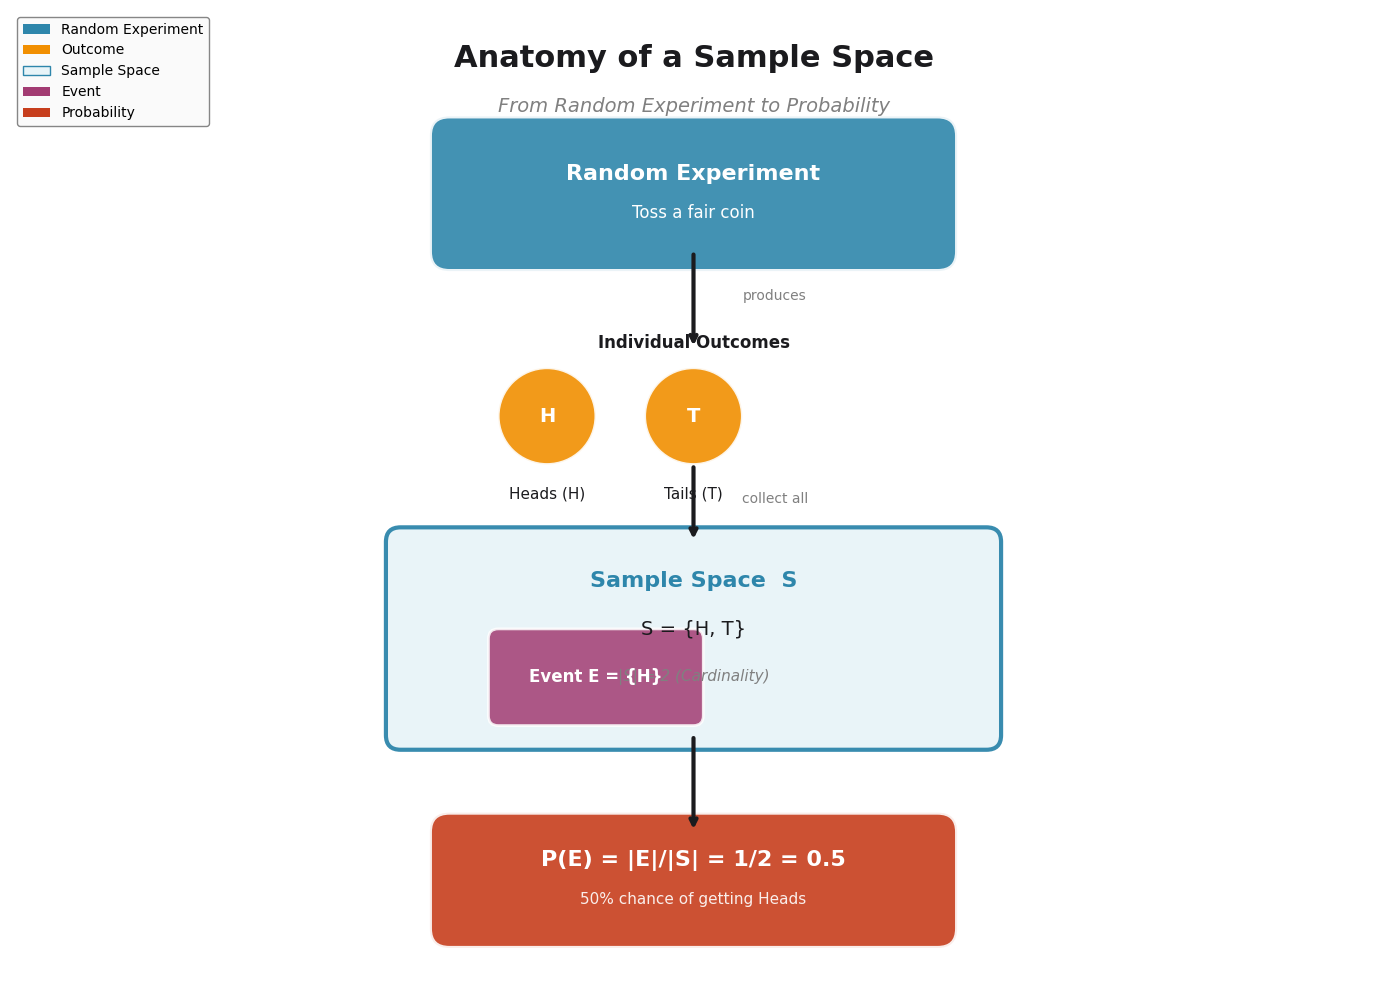


Sample Space Introduction diagram created!
Key Observation: The sample space S contains ALL possible outcomes.
An event E is simply a subset of S.


In [2]:
# =============================================================================
# SECTION 1: SAMPLE SPACE INTRODUCTION VISUALIZATION
# =============================================================================

def create_sample_space_intro():
    fig, ax = plt.subplots(figsize=(14, 10))
    ax.set_xlim(0, 14)
    ax.set_ylim(0, 10)
    ax.axis('off')
    ax.set_facecolor('#FFFFFF')
    
    ax.text(7, 9.5, 'Anatomy of a Sample Space', fontsize=22, fontweight='bold',
            ha='center', va='center', color=COLORS['dark'])
    ax.text(7, 9.0, 'From Random Experiment to Probability', fontsize=14,
            ha='center', va='center', color='gray', style='italic')
    
    # RANDOM EXPERIMENT
    exp_box = FancyBboxPatch((4.5, 7.5), 5, 1.2, 
                              boxstyle="round,pad=0.2", 
                              facecolor=COLORS['primary'], 
                              edgecolor='white', linewidth=3, alpha=0.9)
    ax.add_patch(exp_box)
    ax.text(7, 8.3, 'Random Experiment', fontsize=16, fontweight='bold',
            ha='center', va='center', color='white')
    ax.text(7, 7.9, 'Toss a fair coin', fontsize=12, ha='center', va='center', color='white')
    
    ax.annotate('', xy=(7, 6.5), xytext=(7, 7.5),
                arrowprops=dict(arrowstyle='->', color=COLORS['dark'], lw=3))
    ax.text(7.5, 7.0, 'produces', fontsize=10, ha='left', color='gray')
    
    # OUTCOMES
    outcomes = ['Heads (H)', 'Tails (T)']
    for i, outcome in enumerate(outcomes):
        x_pos = 5.5 + i * 1.5
        circle = Circle((x_pos, 5.8), 0.5, facecolor=COLORS['accent'], 
                        edgecolor='white', linewidth=2, alpha=0.9)
        ax.add_patch(circle)
        ax.text(x_pos, 5.8, outcome[0], fontsize=14, fontweight='bold',
                ha='center', va='center', color='white')
        ax.text(x_pos, 5.0, outcome, fontsize=11, ha='center', va='center', color=COLORS['dark'])
    
    ax.text(7, 6.5, 'Individual Outcomes', fontsize=12, fontweight='bold', 
            ha='center', color=COLORS['dark'])
    
    ax.annotate('', xy=(7, 4.5), xytext=(7, 5.3),
                arrowprops=dict(arrowstyle='->', color=COLORS['dark'], lw=3))
    ax.text(7.5, 4.9, 'collect all', fontsize=10, ha='left', color='gray')
    
    # SAMPLE SPACE
    sample_box = FancyBboxPatch((4, 2.5), 6, 2, 
                                 boxstyle="round,pad=0.15", 
                                 facecolor='#E8F4F8', 
                                 edgecolor=COLORS['primary'], linewidth=3, alpha=0.95)
    ax.add_patch(sample_box)
    ax.text(7, 4.1, 'Sample Space  S', fontsize=16, fontweight='bold', 
            ha='center', va='center', color=COLORS['primary'])
    ax.text(7, 3.6, "S = {H, T}", fontsize=14, ha='center', va='center', 
            color=COLORS['dark'])
    ax.text(7, 3.1, '|S| = 2 (Cardinality)', fontsize=11, ha='center', va='center', 
            color='gray', style='italic')
    
    # EVENT
    event_box = FancyBboxPatch((5, 2.7), 2, 0.8, 
                                boxstyle="round,pad=0.1", 
                                facecolor=COLORS['secondary'], 
                                edgecolor='white', linewidth=2, alpha=0.85)
    ax.add_patch(event_box)
    ax.text(6, 3.1, "Event E = {H}", fontsize=12, fontweight='bold',
            ha='center', va='center', color='white')
    
    ax.annotate('', xy=(7, 1.5), xytext=(7, 2.5),
                arrowprops=dict(arrowstyle='->', color=COLORS['dark'], lw=3))
    
    # PROBABILITY
    prob_box = FancyBboxPatch((4.5, 0.5), 5, 1, 
                               boxstyle="round,pad=0.2", 
                               facecolor=COLORS['success'], 
                               edgecolor='white', linewidth=3, alpha=0.9)
    ax.add_patch(prob_box)
    ax.text(7, 1.2, "P(E) = |E|/|S| = 1/2 = 0.5", 
            fontsize=16, fontweight='bold', ha='center', va='center', color='white')
    ax.text(7, 0.8, '50% chance of getting Heads', fontsize=11, 
            ha='center', va='center', color='white', alpha=0.9)
    
    legend_elements = [
        mpatches.Patch(facecolor=COLORS['primary'], label='Random Experiment'),
        mpatches.Patch(facecolor=COLORS['accent'], label='Outcome'),
        mpatches.Patch(facecolor='#E8F4F8', edgecolor=COLORS['primary'], label='Sample Space'),
        mpatches.Patch(facecolor=COLORS['secondary'], label='Event'),
        mpatches.Patch(facecolor=COLORS['success'], label='Probability')
    ]
    ax.legend(handles=legend_elements, loc='upper left', fontsize=10, 
              framealpha=0.95, edgecolor='gray')
    
    plt.tight_layout()
    plt.show()
    return fig

fig_intro = create_sample_space_intro()
print("\nSample Space Introduction diagram created!")
print("Key Observation: The sample space S contains ALL possible outcomes.")
print("An event E is simply a subset of S.")


---

# 2. Coin Toss Sample Space

## Concept Overview

A **coin toss** is the simplest random experiment. Each toss has two outcomes: **Heads (H)** or **Tails (T)**.

### Mathematical Foundation

For $n$ coins, the sample space is the set of all possible sequences of H and T:

$$S_n = \{(x_1, x_2, \ldots, x_n) : x_i \in \{H, T\}\}$$

The **cardinality** grows exponentially:

$$|S_n| = 2^n$$

| Coins | Sample Space | $|S|$ |
|-------|-------------|-------|
| 1 | $\{H, T\}$ | 2 |
| 2 | $\{HH, HT, TH, TT\}$ | 4 |
| 3 | $\{HHH, HHT, HTH, HTT, THH, THT, TTH, TTT\}$ | 8 |
| 4 | 16 sequences | 16 |

### Learning Objective

Understand how the sample space grows with the number of experiments and visualize this exponential growth.

### AI Relevance

- **Binary classification**: Coin tosses model binary decisions (Yes/No, Spam/Not Spam)
- **Decision trees**: Each split is like a coin toss — binary branching
- **Bit strings**: $n$ coins = $n$-bit binary string, fundamental in computing

---

## Interactive Visualization: Coin Toss Explorer


In [3]:
# =============================================================================
# SECTION 2: COIN TOSS SAMPLE SPACE - INTERACTIVE VISUALIZATION
# =============================================================================

def generate_coin_outcomes(n_coins):
    if n_coins == 0:
        return ['']
    outcomes = []
    for i in range(2 ** n_coins):
        binary = format(i, '0{}b'.format(n_coins))
        outcome = binary.replace('0', 'H').replace('1', 'T')
        outcomes.append(outcome)
    return outcomes

def visualize_coin_sample_space(n_coins):
    outcomes = generate_coin_outcomes(n_coins)
    total = len(outcomes)
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 8), gridspec_kw={'width_ratios': [1, 1.2]})
    
    ax1 = axes[0]
    ax1.set_xlim(0, 10)
    ax1.set_ylim(0, 10)
    ax1.axis('off')
    ax1.set_facecolor('#FAFAFA')
    
    ax1.text(5, 9.5, f'{n_coins} Coin Sample Space', 
             fontsize=18, fontweight='bold', ha='center', color=COLORS['dark'])
    ax1.text(5, 9.0, f'Total Outcomes: |S| = 2^{n_coins} = {total}', 
             fontsize=14, ha='center', color=COLORS['primary'])
    
    cols = min(4, total)
    rows = (total + cols - 1) // cols
    box_w = 8 / cols
    box_h = 7 / max(rows, 1)
    
    for idx, outcome in enumerate(outcomes):
        row = idx // cols
        col = idx % cols
        x = 1 + col * box_w
        y = 8 - row * box_h - 0.5
        
        n_heads = outcome.count('H')
        color_intensity = n_heads / n_coins if n_coins > 0 else 0.5
        color = plt.cm.viridis(color_intensity)
        
        rect = FancyBboxPatch((x, y - box_h + 0.3), box_w - 0.3, box_h - 0.3,
                               boxstyle="round,pad=0.05",
                               facecolor=color, edgecolor='white', linewidth=2, alpha=0.9)
        ax1.add_patch(rect)
        
        coin_size = 0.25
        start_x = x + (box_w - 0.3) / 2 - (n_coins * coin_size) / 2
        for i, face in enumerate(outcome):
            cx = start_x + i * coin_size * 1.5
            cy = y - box_h / 2 + 0.1
            coin_color = COLORS['coin_heads'] if face == 'H' else COLORS['coin_tails']
            coin = Circle((cx, cy), coin_size / 2, facecolor=coin_color, 
                          edgecolor='white', linewidth=1.5)
            ax1.add_patch(coin)
            ax1.text(cx, cy, face, fontsize=8, fontweight='bold', 
                    ha='center', va='center', color='black')
        
        ax1.text(x + (box_w - 0.3) / 2, y - box_h + 0.5, f'#{idx+1}', 
                fontsize=8, ha='center', color='white', alpha=0.8)
    
    ax2 = axes[1]
    n_range = range(1, 7)
    sizes = [2**n for n in n_range]
    
    bars = ax2.bar(n_range, sizes, color=plt.cm.plasma(np.linspace(0.2, 0.8, 6)), 
                   edgecolor='white', linewidth=2, alpha=0.9)
    
    if n_coins in n_range:
        bars[n_coins - 1].set_edgecolor(COLORS['accent'])
        bars[n_coins - 1].set_linewidth(4)
    
    ax2.set_xlabel('Number of Coins (n)', fontsize=13, fontweight='bold')
    ax2.set_ylabel('Sample Space Size |S| = 2^n', fontsize=13, fontweight='bold')
    ax2.set_title('Exponential Growth of Sample Space', fontsize=15, fontweight='bold')
    ax2.set_xticks(list(n_range))
    ax2.set_yscale('log')
    ax2.grid(True, alpha=0.3, which='both')
    
    for bar, size in zip(bars, sizes):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height * 1.1,
                f'{size}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    ax2.annotate('Exponential! Each coin DOUBLES the space', 
                xy=(4, 2**4), xytext=(5, 2**5.5),
                arrowprops=dict(arrowstyle='->', color=COLORS['accent'], lw=2),
                fontsize=11, color=COLORS['accent'], fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.3))
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nSample Space for {n_coins} coin(s):")
    print(f"   S = {{{', '.join(outcomes)}}}")
    print(f"   |S| = {total}")
    print(f"Key Insight: Each additional coin DOUBLES the sample space size!")
    return outcomes

@interact(n_coins=widgets.IntSlider(min=1, max=5, step=1, value=2, 
                                   description='Coins:', style={'description_width': '80px'},
                                   layout=Layout(width='400px')))
def interactive_coin_explorer(n_coins):
    visualize_coin_sample_space(n_coins)


interactive(children=(IntSlider(value=2, description='Coins:', layout=Layout(width='400px'), max=5, min=1, sty…

---

# 3. Dice Roll Sample Space

## Concept Overview

A standard die has 6 faces numbered 1 through 6. When rolling multiple dice, the sample space is the **Cartesian product** of individual die sample spaces.

### Mathematical Foundation

For $n$ dice, each with $m$ faces:

$$S_n = \{(d_1, d_2, \ldots, d_n) : d_i \in \{1, 2, \ldots, m\}\}$$

The cardinality is:

$$|S_n| = m^n = 6^n$$

| Dice | Sample Space Description | $|S|$ |
|------|------------------------|-------|
| 1 | $\{1, 2, 3, 4, 5, 6\}$ | 6 |
| 2 | Ordered pairs $(d_1, d_2)$ | 36 |
| 3 | Ordered triples $(d_1, d_2, d_3)$ | 216 |

### Cartesian Product

For two dice:

$$S = D_1 \times D_2 = \{(i, j) : i \in D_1, j \in D_2\}$$

where $D_1 = D_2 = \{1, 2, 3, 4, 5, 6\}$.

### Learning Objective

Visualize the Cartesian product structure and understand ordered vs. unordered outcomes.

### AI Relevance

- **Multi-class classification**: Dice faces represent class labels
- **Game AI**: State spaces in board games (e.g., backgammon uses dice)
- **Hyperparameter search**: Grid search samples from Cartesian product of hyperparameters

---

## Interactive Visualization: Dice Roll Explorer


In [4]:
# =============================================================================
# SECTION 3: DICE ROLL SAMPLE SPACE - INTERACTIVE VISUALIZATION
# =============================================================================

def visualize_dice_sample_space(n_dice=2):
    if n_dice == 1:
        fig, ax = plt.subplots(figsize=(14, 4))
        faces = list(range(1, 7))
        colors = plt.cm.viridis(np.linspace(0.1, 0.9, 6))
        
        for i, (face, color) in enumerate(zip(faces, colors)):
            rect = FancyBboxPatch((i * 2 + 0.5, 0.5), 1.5, 2,
                                   boxstyle="round,pad=0.1",
                                   facecolor=color, edgecolor='white', linewidth=3)
            ax.add_patch(rect)
            ax.text(i * 2 + 1.25, 1.5, str(face), fontsize=28, fontweight='bold',
                   ha='center', va='center', color='white')
        
        ax.set_xlim(0, 13)
        ax.set_ylim(0, 3.5)
        ax.axis('off')
        ax.set_title('Single Die Sample Space: S = {1, 2, 3, 4, 5, 6} |S| = 6', 
                    fontsize=16, fontweight='bold', pad=20)
        plt.show()
        
    elif n_dice == 2:
        fig, axes = plt.subplots(1, 2, figsize=(16, 8))
        
        ax1 = axes[0]
        for i in range(1, 7):
            for j in range(1, 7):
                color = plt.cm.plasma((i + j - 2) / 10)
                rect = plt.Rectangle((i - 0.4, j - 0.4), 0.8, 0.8,
                                     facecolor=color, edgecolor='white', linewidth=2)
                ax1.add_patch(rect)
                ax1.text(i, j, f'({i},{j})', fontsize=9, ha='center', va='center',
                        color='white', fontweight='bold')
        
        ax1.set_xlim(0.5, 6.5)
        ax1.set_ylim(0.5, 6.5)
        ax1.set_xticks(range(1, 7))
        ax1.set_yticks(range(1, 7))
        ax1.set_xlabel('Die 1', fontsize=13, fontweight='bold')
        ax1.set_ylabel('Die 2', fontsize=13, fontweight='bold')
        ax1.set_title('Cartesian Product Grid |S| = 36', fontsize=14, fontweight='bold')
        ax1.set_aspect('equal')
        ax1.grid(True, alpha=0.2)
        
        ax2 = axes[1]
        sums = [i + j for i in range(1, 7) for j in range(1, 7)]
        sum_counts = pd.Series(sums).value_counts().sort_index()
        
        bars = ax2.bar(sum_counts.index, sum_counts.values, 
                      color=plt.cm.inferno(np.linspace(0.2, 0.8, 11)),
                      edgecolor='white', linewidth=2)
        ax2.set_xlabel('Sum of Two Dice', fontsize=13, fontweight='bold')
        ax2.set_ylabel('Frequency', fontsize=13, fontweight='bold')
        ax2.set_title('Sum Distribution (Event Frequencies)', fontsize=14, fontweight='bold')
        ax2.set_xticks(range(2, 13))
        
        for bar, count in zip(bars, sum_counts.values):
            prob = count / 36
            ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.2,
                    f'{count}/36 ({prob:.2%})', ha='center', va='bottom', 
                    fontsize=9, fontweight='bold')
        
        plt.tight_layout()
        plt.show()
        
    else:
        fig = plt.figure(figsize=(14, 10))
        ax = fig.add_subplot(111, projection='3d')
        
        outcomes = [(i, j, k) for i in range(1, 7) for j in range(1, 7) for k in range(1, 7)]
        xs, ys, zs = zip(*outcomes)
        sums = [x + y + z for x, y, z in outcomes]
        
        scatter = ax.scatter(xs, ys, zs, c=sums, cmap='viridis', 
                           s=50, alpha=0.8, edgecolors='white', linewidth=0.5)
        
        ax.set_xlabel('Die 1', fontsize=12, fontweight='bold')
        ax.set_ylabel('Die 2', fontsize=12, fontweight='bold')
        ax.set_zlabel('Die 3', fontsize=12, fontweight='bold')
        ax.set_title(f'Three Dice Sample Space |S| = 216', fontsize=16, fontweight='bold', pad=20)
        
        cbar = plt.colorbar(scatter, ax=ax, shrink=0.6, aspect=15)
        cbar.set_label('Sum', fontsize=11, fontweight='bold')
        plt.show()
    
    total = 6 ** n_dice
    print(f"\nSample Space for {n_dice} die/dice:")
    print(f"   |S| = 6^{n_dice} = {total}")
    print(f"Key Insight: The sample space is the Cartesian product of individual die spaces!")

@interact(n_dice=widgets.Dropdown(options=[1, 2, 3], value=2, 
                                 description='Dice:', style={'description_width': '80px'}))
def interactive_dice_explorer(n_dice):
    visualize_dice_sample_space(n_dice)


interactive(children=(Dropdown(description='Dice:', index=1, options=(1, 2, 3), style=DescriptionStyle(descrip…

---

# 4. Tree Diagram Generator

## Concept Overview

**Tree diagrams** are powerful tools for visualizing multi-stage random experiments. Each branch represents a possible outcome at each stage.

### Mathematical Foundation

For a sequence of experiments, the sample space can be represented as paths through a tree:

- **Root**: Start of the experiment
- **Branches**: Possible outcomes at each stage
- **Leaves**: Complete outcomes (elements of $S$)
- **Depth**: Number of stages

For $n$ coin tosses, the tree has:
- $2^n$ leaves (outcomes)
- $2^{n+1} - 2$ total branches
- Depth $n$

### Learning Objective

Understand how sequential experiments build sample spaces through tree structures, and how probability propagates along branches.

### AI Relevance

- **Decision trees**: ML algorithms that partition feature space like probability trees
- **Game trees**: In chess/Go AI, each node is a state, branches are moves
- **Hidden Markov Models**: State transitions form a tree-like structure
- **Monte Carlo Tree Search**: Used in AlphaGo for game state exploration

---

## Interactive Tree Diagram Generator


In [ ]:
# =============================================================================
# SECTION 4: TREE DIAGRAM GENERATOR
# =============================================================================

def draw_tree_diagram(experiment='coin', stages=3, figsize=(16, 10)):
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_xlim(-1, 2**stages + 1)
    ax.set_ylim(-1, stages + 1)
    ax.axis('off')
    ax.set_facecolor('#FAFAFA')
    
    if experiment == 'coin':
        outcomes = ['H', 'T']
        colors = [COLORS['coin_heads'], COLORS['coin_tails']]
        title = f'Coin Toss Tree Diagram ({stages} tosses)'
    elif experiment == 'die':
        outcomes = ['1', '2', '3', '4', '5', '6']
        colors = plt.cm.viridis(np.linspace(0.1, 0.9, 6))
        title = f'Dice Roll Tree Diagram ({stages} rolls)'
    elif experiment == 'card':
        outcomes = ['S', 'H', 'D', 'C']
        colors = [COLORS['card_spades'], COLORS['card_hearts'], 
                 COLORS['card_diamonds'], COLORS['card_clubs']]
        title = f'Card Draw Tree Diagram ({stages} draws)'
    else:
        outcomes = ['A', 'B']
        colors = [COLORS['primary'], COLORS['secondary']]
        title = f'Generic Tree Diagram ({stages} stages)'
    
    n_outcomes = len(outcomes)
    total_leaves = n_outcomes ** stages
    
    ax.text(2**(stages-1), stages + 0.5, title, fontsize=18, fontweight='bold',
            ha='center', color=COLORS['dark'])
    ax.text(2**(stages-1), stages, f'Total Outcomes: |S| = {n_outcomes}^{stages} = {total_leaves}', 
            fontsize=13, ha='center', color=COLORS['primary'])
    
    def draw_node(x, y, label, color, size=0.3):
        circle = Circle((x, y), size, facecolor=color, edgecolor='white', linewidth=2)
        ax.add_patch(circle)
        ax.text(x, y, label, fontsize=10, fontweight='bold', 
               ha='center', va='center', color='white')
    
    def draw_branch(x1, y1, x2, y2, color, width=2):
        ax.plot([x1, x2], [y1, y2], color=color, linewidth=width, alpha=0.7)
    
    def build_tree(level, x_pos, y_pos, width, path):
        if level == stages:
            draw_node(x_pos, y_pos, ''.join(path), '#2E86AB', size=0.25)
            return
        
        if level == 0:
            draw_node(x_pos, y_pos, 'Start', COLORS['dark'], size=0.35)
        
        branch_width = width / n_outcomes
        for i, (outcome, color) in enumerate(zip(outcomes, colors)):
            new_x = x_pos - width/2 + branch_width * (i + 0.5)
            new_y = y_pos - 1.2
            
            draw_branch(x_pos, y_pos - 0.3, new_x, new_y + 0.3, color, width=2.5)
            
            if level < stages - 1:
                draw_node(new_x, new_y, outcome, color, size=0.25)
            
            build_tree(level + 1, new_x, new_y, branch_width, path + [outcome])
    
    build_tree(0, 2**(stages-1), stages - 0.5, 2**stages, [])
    
    legend_elements = [mpatches.Patch(facecolor=c, label=o) 
                      for o, c in zip(outcomes, colors)]
    ax.legend(handles=legend_elements, loc='lower right', fontsize=11, 
             title='Outcomes', title_fontsize=12, framealpha=0.95)
    
    plt.tight_layout()
    plt.show()
    
    print(f"Tree Diagram Summary:")
    print(f"   Experiment: {experiment.title()}")
    print(f"   Stages: {stages}")
    print(f"   Branches per node: {n_outcomes}")
    print(f"   Total leaves (outcomes): {total_leaves}")
    print(f"   |S| = {n_outcomes}^{stages} = {total_leaves}")

@interact(
    experiment=widgets.Dropdown(options=['coin', 'die', 'card'], value='coin',
                                description='Experiment:', style={'description_width': '100px'}),
    stages=widgets.IntSlider(min=1, max=4, step=1, value=3,
                             description='Stages:', style={'description_width': '100px'})
)
def interactive_tree_generator(experiment, stages):
    draw_tree_diagram(experiment, stages)


interactive(children=(Dropdown(description='Experiment:', options=('coin', 'die', 'card'), style=DescriptionSt…

---

# 5. Venn Diagram of Events

## Concept Overview

**Venn diagrams** visualize relationships between events and the sample space. They are essential for understanding set operations in probability.

### Mathematical Foundation

Given sample space $S$ and events $A, B \subseteq S$:

| Operation | Notation | Meaning |
|-----------|----------|---------|
| **Union** | $A \cup B$ | Outcomes in A OR B | 
| **Intersection** | $A \cap B$ | Outcomes in A AND B |
| **Complement** | $A^c$ or $\bar{A}$ | Outcomes NOT in A |
| **Difference** | $A \setminus B$ | Outcomes in A but not B |

### Probability Formulas

$$P(A \cup B) = P(A) + P(B) - P(A \cap B)$$

$$P(A^c) = 1 - P(A)$$

$$P(A \cap B) = P(A) \cdot P(B) \quad \text{(if independent)}$$

### Learning Objective

Visualize set operations and understand how they relate to probability calculations.

### AI Relevance

- **Feature intersection**: $A \cap B$ represents co-occurring features
- **Ensemble methods**: Union of predictions from multiple models
- **Bayesian networks**: Conditional probability through set intersections
- **Multi-label classification**: Each label is an event in the sample space

---

## Interactive Venn Diagram Explorer


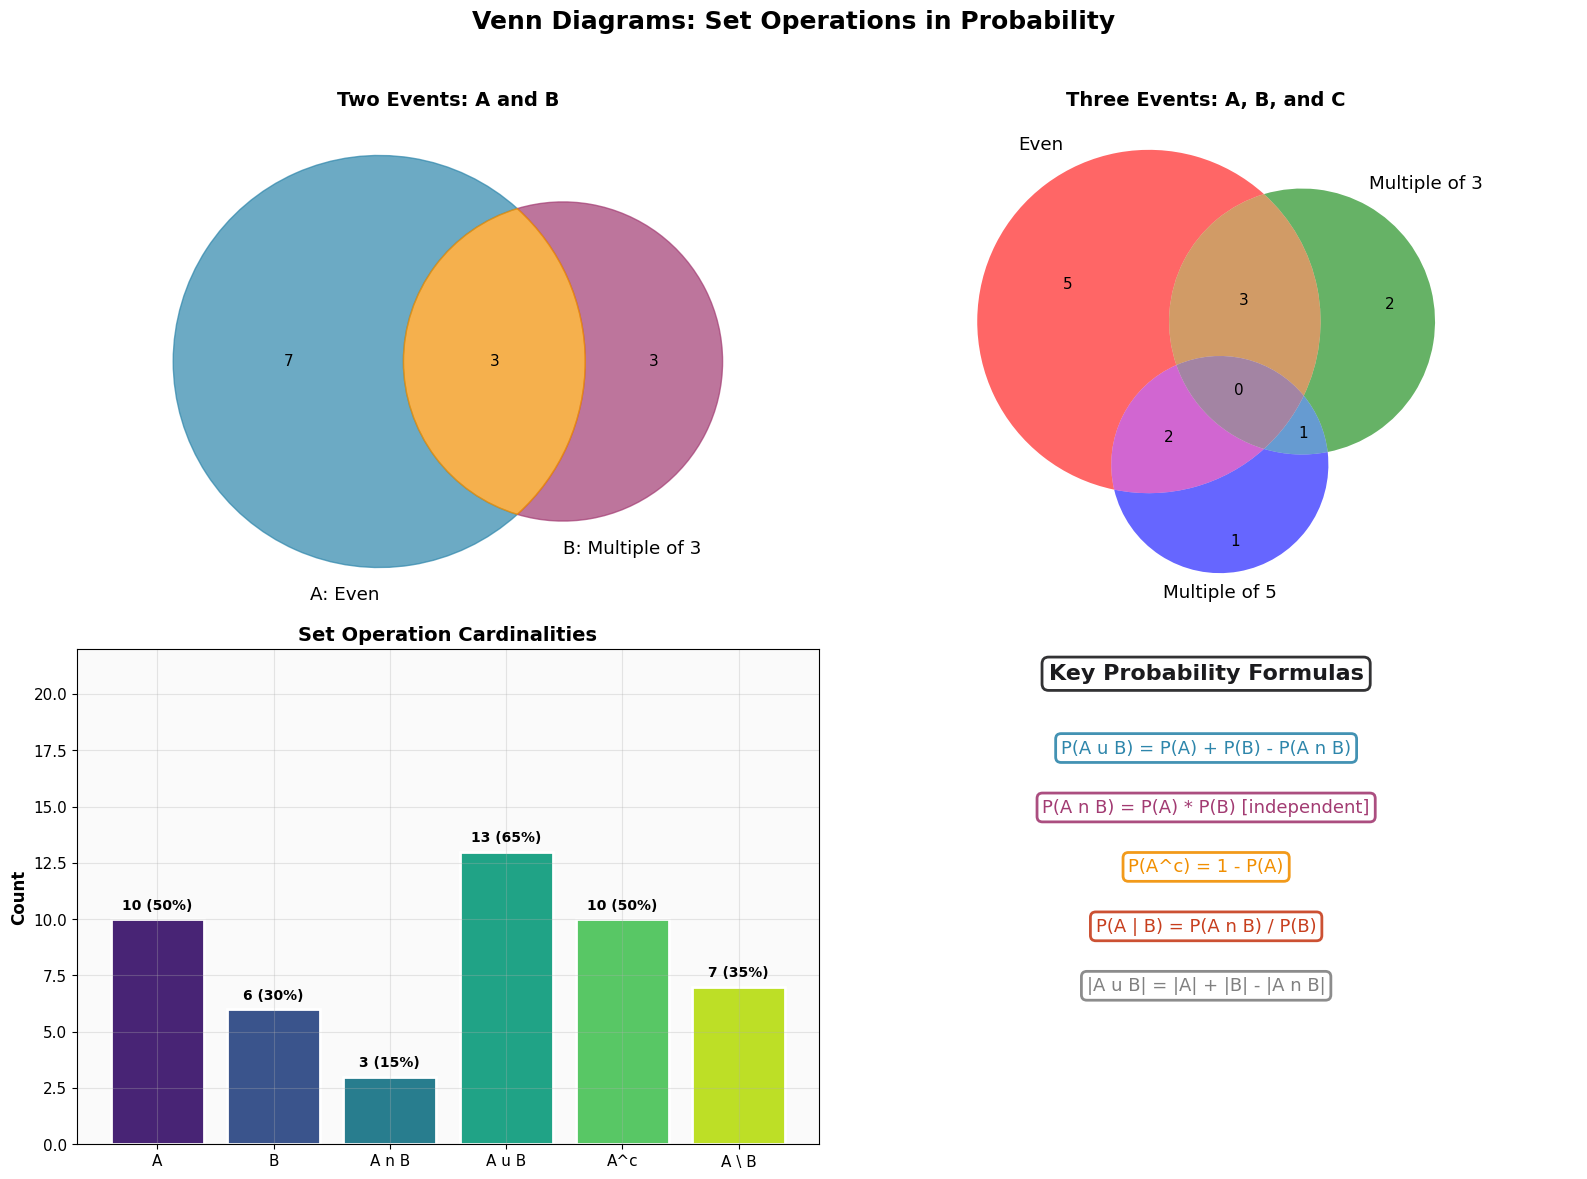

Set Operation Results (Sample Space S = {1, ..., 20}):
   A (Even): [2, 4, 6, 8, 10, 12, 14, 16, 18, 20]
   B (Multiple of 3): [3, 6, 9, 12, 15, 18]
   A n B (Even AND Multiple of 3): [6, 12, 18]
   A u B (Even OR Multiple of 3): [2, 3, 4, 6, 8, 9, 10, 12, 14, 15, 16, 18, 20]
   A^c (NOT Even): [1, 3, 5, 7, 9, 11, 13, 15, 17, 19]
Key Insight: Venn diagrams make set operations intuitive!


In [6]:
# =============================================================================
# SECTION 5: VENN DIAGRAM OF EVENTS
# =============================================================================

def create_venn_explorer():
    S = set(range(1, 21))
    A = set(range(2, 21, 2))
    B = set(range(3, 21, 3))
    C = set(range(5, 21, 5))
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Venn Diagrams: Set Operations in Probability', 
                fontsize=18, fontweight='bold', y=0.98)
    
    ax1 = axes[0, 0]
    v = venn2([A, B], set_labels=('A: Even', 'B: Multiple of 3'), ax=ax1)
    ax1.set_title('Two Events: A and B', fontsize=14, fontweight='bold')
    
    if v:
        v.get_patch_by_id('10').set_color(COLORS['primary'])
        v.get_patch_by_id('01').set_color(COLORS['secondary'])
        v.get_patch_by_id('11').set_color(COLORS['accent'])
        for patch in v.patches:
            patch.set_alpha(0.7)
    
    ax2 = axes[0, 1]
    v3 = venn3([A, B, C], set_labels=('Even', 'Multiple of 3', 'Multiple of 5'), ax=ax2)
    ax2.set_title('Three Events: A, B, and C', fontsize=14, fontweight='bold')
    
    if v3:
        for patch in v3.patches:
            if patch:
                patch.set_alpha(0.6)
    
    ax3 = axes[1, 0]
    operations = ['A', 'B', 'A n B', 'A u B', 'A^c', 'A \\ B']
    sizes = [len(A), len(B), len(A & B), len(A | B), len(S - A), len(A - B)]
    probs = [s / len(S) for s in sizes]
    
    bars = ax3.bar(operations, sizes, color=plt.cm.viridis(np.linspace(0.1, 0.9, 6)),
                   edgecolor='white', linewidth=2)
    ax3.set_ylabel('Count', fontsize=12, fontweight='bold')
    ax3.set_title('Set Operation Cardinalities', fontsize=14, fontweight='bold')
    ax3.set_ylim(0, len(S) + 2)
    
    for bar, size, prob in zip(bars, sizes, probs):
        ax3.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
                f'{size} ({prob:.0%})', ha='center', va='bottom', 
                fontsize=10, fontweight='bold')
    
    ax4 = axes[1, 1]
    ax4.set_xlim(0, 10)
    ax4.set_ylim(0, 10)
    ax4.axis('off')
    ax4.set_facecolor('#F8F9FA')
    
    formulas = [
        ('Key Probability Formulas', 9.5, 16, COLORS['dark']),
        ('P(A u B) = P(A) + P(B) - P(A n B)', 8.0, 13, COLORS['primary']),
        ('P(A n B) = P(A) * P(B) [independent]', 6.8, 13, COLORS['secondary']),
        ('P(A^c) = 1 - P(A)', 5.6, 13, COLORS['accent']),
        ('P(A | B) = P(A n B) / P(B)', 4.4, 13, COLORS['success']),
        ('|A u B| = |A| + |B| - |A n B|', 3.2, 13, 'gray'),
    ]
    
    for text, y, size, color in formulas:
        weight = 'bold' if size > 14 else 'normal'
        ax4.text(5, y, text, fontsize=size, fontweight=weight,
                ha='center', va='center', color=color,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', 
                         edgecolor=color, alpha=0.9, linewidth=2))
    
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()
    
    print("Set Operation Results (Sample Space S = {1, ..., 20}):")
    print(f"   A (Even): {sorted(A)}")
    print(f"   B (Multiple of 3): {sorted(B)}")
    print(f"   A n B (Even AND Multiple of 3): {sorted(A & B)}")
    print(f"   A u B (Even OR Multiple of 3): {sorted(A | B)}")
    print(f"   A^c (NOT Even): {sorted(S - A)}")
    print(f"Key Insight: Venn diagrams make set operations intuitive!")

create_venn_explorer()


---

# 6. Set Representation Explorer

## Concept Overview

Sample spaces can be represented as **mathematical sets** in various forms: roster notation, set-builder notation, and interval notation.

### Mathematical Foundation

| Notation | Form | Example |
|----------|------|---------|
| **Roster** | List elements | $S = \{H, T\}$ |
| **Set-builder** | Rule-based | $S = \{x : x \in \{H, T\}\}$ |
| **Interval** | Continuous range | $S = [0, 1]$ |
| **Cartesian product** | Ordered pairs | $S = A \times B$ |

### Learning Objective

Understand different set representations and when to use each form.

### AI Relevance

- **Feature spaces**: $S = \mathbb{R}^d$ (d-dimensional real space)
- **Vocabulary sets**: $S = \{w_1, w_2, \ldots, w_V\}$ (V = vocabulary size)
- **Action spaces**: $S = \{a_1, a_2, \ldots, a_n\}$ in RL
- **Hypothesis spaces**: All possible model parameters

---

## Interactive Set Representation Dashboard


In [7]:
# =============================================================================
# SECTION 6: SET REPRESENTATION EXPLORER
# =============================================================================

def explore_set_representations(experiment='coin'):
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Set Representation Explorer', fontsize=18, fontweight='bold', y=0.98)
    
    if experiment == 'coin':
        S = ['H', 'T']
        name = 'Coin Toss'
        symbol = 'S = {H, T}'
        builder = 'S = {w : w in {H, T}}'
        cardinality = '|S| = 2'
        ai_app = 'Binary Classification: {Spam, Not Spam}'
    elif experiment == 'dice':
        S = list(range(1, 7))
        name = 'Dice Roll'
        symbol = 'S = {1, 2, 3, 4, 5, 6}'
        builder = 'S = {w : w in N, 1 <= w <= 6}'
        cardinality = '|S| = 6'
        ai_app = 'Multi-class: {Cat, Dog, Bird, Fish, Horse, Deer}'
    elif experiment == 'cards':
        suits = ['S', 'H', 'D', 'C']
        ranks = ['A', '2', '3', '4', '5', '6', '7', '8', '9', '10', 'J', 'Q', 'K']
        S = [f'{r}{s}' for s in suits for r in ranks]
        name = 'Playing Cards'
        symbol = 'S = {AS, 2S, ..., KC}'
        builder = 'S = {(r, s) : r in Ranks, s in Suits}'
        cardinality = '|S| = 52'
        ai_app = 'Image Classification: 1000 ImageNet classes'
    elif experiment == 'weather':
        S = ['Sunny', 'Cloudy', 'Rainy', 'Snowy']
        name = 'Weather'
        symbol = 'S = {Sunny, Cloudy, Rainy, Snowy}'
        builder = 'S = {w : w is a weather condition}'
        cardinality = '|S| = 4'
        ai_app = 'Weather Prediction: Multi-class classifier'
    else:
        S = ['Class_A', 'Class_B', 'Class_C', 'Class_D', 'Class_E']
        name = 'AI Classification'
        symbol = 'S = {Class_A, ..., Class_E}'
        builder = 'S = {c : c is a possible class label}'
        cardinality = '|S| = 5'
        ai_app = 'Neural Network Output: Softmax over classes'
    
    ax1 = axes[0, 0]
    ax1.set_xlim(0, 10)
    ax1.set_ylim(0, 10)
    ax1.axis('off')
    ax1.set_facecolor('#E8F4F8')
    ax1.text(5, 9, 'Roster Notation', fontsize=16, fontweight='bold', 
            ha='center', color=COLORS['primary'])
    ax1.text(5, 7.5, f'Sample Space: {name}', fontsize=13, ha='center', color=COLORS['dark'])
    ax1.text(5, 6.5, symbol, fontsize=14, ha='center', color=COLORS['dark'],
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor=COLORS['primary'], linewidth=2))
    ax1.text(5, 5, f'Elements: {len(S)}', fontsize=12, ha='center', color='gray')
    
    n_show = min(len(S), 8)
    for i, elem in enumerate(S[:n_show]):
        x = 1.5 + (i % 4) * 2
        y = 3.5 - (i // 4) * 1.5
        circle = Circle((x, y), 0.6, facecolor=plt.cm.viridis(i / max(n_show, 1)), 
                       edgecolor='white', linewidth=2, alpha=0.9)
        ax1.add_patch(circle)
        ax1.text(x, y, str(elem)[:3], fontsize=10, fontweight='bold',
                ha='center', va='center', color='white')
    
    if len(S) > n_show:
        ax1.text(5, 1.5, f'+ {len(S) - n_show} more...', fontsize=10, 
                ha='center', color='gray', style='italic')
    
    ax2 = axes[0, 1]
    ax2.set_xlim(0, 10)
    ax2.set_ylim(0, 10)
    ax2.axis('off')
    ax2.set_facecolor('#F3E8F8')
    ax2.text(5, 9, 'Set-Builder Notation', fontsize=16, fontweight='bold',
            ha='center', color=COLORS['secondary'])
    ax2.text(5, 7, 'Define by property/rule:', fontsize=12, ha='center', color='gray')
    ax2.text(5, 5.5, builder, fontsize=13, ha='center', color=COLORS['dark'],
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', 
                     edgecolor=COLORS['secondary'], linewidth=2))
    ax2.text(5, 4, 'Useful for infinite or large sets', fontsize=11, 
            ha='center', color='gray', style='italic')
    
    ax3 = axes[1, 0]
    ax3.set_xlim(0, 10)
    ax3.set_ylim(0, 10)
    ax3.axis('off')
    ax3.set_facecolor('#E8F8E8')
    ax3.text(5, 9, 'Cardinality |S|', fontsize=16, fontweight='bold',
            ha='center', color=COLORS['success'])
    ax3.text(5, 7, 'Number of elements in the sample space:', fontsize=12, 
            ha='center', color='gray')
    ax3.text(5, 5.5, cardinality, fontsize=20, fontweight='bold', 
            ha='center', color=COLORS['success'],
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', 
                     edgecolor=COLORS['success'], linewidth=3))
    ax3.text(5, 3.5, 'Determines the denominator in probability calculations', 
            fontsize=11, ha='center', color='gray', style='italic')
    
    ax4 = axes[1, 1]
    ax4.set_xlim(0, 10)
    ax4.set_ylim(0, 10)
    ax4.axis('off')
    ax4.set_facecolor('#FFF8E8')
    ax4.text(5, 9, 'AI Application', fontsize=16, fontweight='bold',
            ha='center', color=COLORS['accent'])
    ax4.text(5, 7, 'How this sample space appears in ML:', fontsize=12, 
            ha='center', color='gray')
    ax4.text(5, 5.5, ai_app, fontsize=12, ha='center', color=COLORS['dark'],
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', 
                     edgecolor=COLORS['accent'], linewidth=2))
    ax4.text(5, 3.5, 'The model learns to predict probabilities over this space', 
            fontsize=11, ha='center', color='gray', style='italic')
    
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()
    
    print(f"Set Representation: {name}")
    print(f"   Roster: {symbol}")
    print(f"   Cardinality: {cardinality}")
    print(f"   AI Context: {ai_app}")

@interact(experiment=widgets.Dropdown(
    options=['coin', 'dice', 'cards', 'weather', 'classification'],
    value='coin', description='Experiment:', style={'description_width': '100px'}
))
def interactive_set_explorer(experiment):
    explore_set_representations(experiment)


interactive(children=(Dropdown(description='Experiment:', options=('coin', 'dice', 'cards', 'weather', 'classi…

---

# 7. Finite vs Infinite Sample Space

## Concept Overview

Sample spaces can be **finite** (countable, limited), **countably infinite** (infinite but listable), or **uncountable/continuous** (real-valued).

### Mathematical Foundation

| Type | Notation | Example | Cardinality |
|------|----------|---------|-------------|
| **Finite** | $S = \{1, 2, 3, 4, 5, 6\}$ | Die roll | $|S| = 6$ |
| **Countably Infinite** | $S = \{0, 1, 2, \ldots\}$ | Poisson events | $|S| = \aleph_0$ |
| **Continuous** | $S = [0, \infty)$ | Time until failure | $|S| = \mathfrak{c}$ |

### Key Differences

- **Finite**: Can enumerate all outcomes
- **Countably Infinite**: Can list outcomes (e.g., integers), but never finish
- **Continuous**: Uncountable — between any two points, infinitely many outcomes

### Learning Objective

Distinguish between finite, countably infinite, and continuous sample spaces, and understand how probability is computed in each case.

### AI Relevance

- **Finite**: Classification with fixed classes, vocabulary of tokens
- **Countably Infinite**: Sequence generation (all possible sentence lengths)
- **Continuous**: Neural network weights, regression outputs, time series

---

## Animated Number Line Visualization


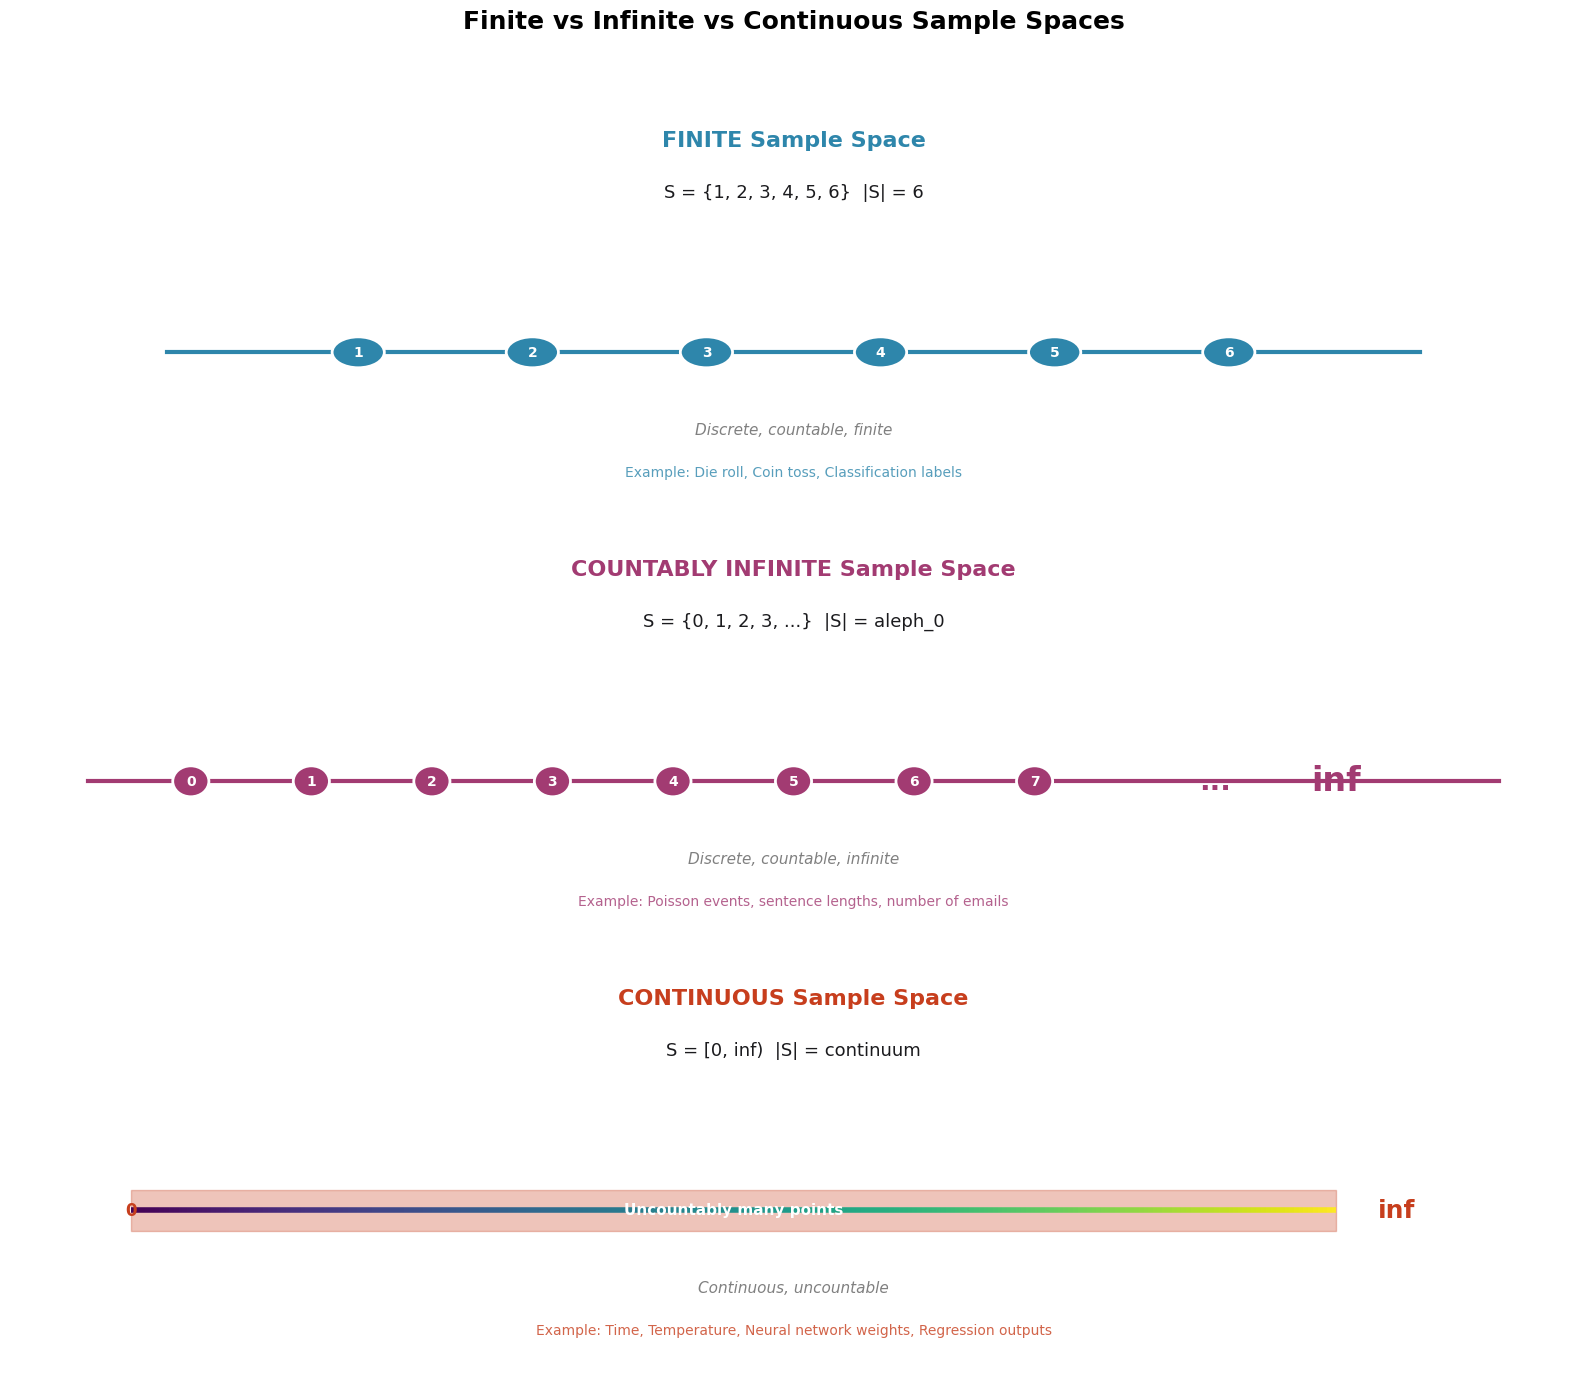

Sample Space Types Comparison:
   Finite:        S = {1,2,3,4,5,6}      |S| = 6
   Countable:     S = {0,1,2,...}         |S| = aleph_0
   Continuous:    S = [0, inf)            |S| = continuum
Key Insight: The type of sample space determines how we compute probability!
   - Finite: P(E) = |E|/|S|
   - Continuous: P(E) = integral_E f(x) dx


In [8]:
# =============================================================================
# SECTION 7: FINITE VS INFINITE SAMPLE SPACE
# =============================================================================

def visualize_sample_space_types():
    fig, axes = plt.subplots(3, 1, figsize=(16, 14))
    fig.suptitle('Finite vs Infinite vs Continuous Sample Spaces', 
                fontsize=18, fontweight='bold', y=0.98)
    
    ax1 = axes[0]
    ax1.set_xlim(-1, 8)
    ax1.set_ylim(-1, 3)
    ax1.axis('off')
    ax1.set_facecolor('#E8F4F8')
    ax1.text(3.5, 2.5, 'FINITE Sample Space', fontsize=16, fontweight='bold',
            ha='center', color=COLORS['primary'])
    ax1.text(3.5, 2.0, 'S = {1, 2, 3, 4, 5, 6}  |S| = 6', fontsize=13, 
            ha='center', color=COLORS['dark'])
    ax1.axhline(y=0.5, xmin=0.1, xmax=0.9, color=COLORS['primary'], linewidth=3)
    for i in range(1, 7):
        circle = Circle((i, 0.5), 0.15, facecolor=COLORS['primary'], 
                       edgecolor='white', linewidth=2, zorder=5)
        ax1.add_patch(circle)
        ax1.text(i, 0.5, str(i), fontsize=10, fontweight='bold', 
                ha='center', va='center', color='white', zorder=6)
    ax1.text(3.5, -0.3, 'Discrete, countable, finite', fontsize=11, 
            ha='center', color='gray', style='italic')
    ax1.text(3.5, -0.7, 'Example: Die roll, Coin toss, Classification labels', 
            fontsize=10, ha='center', color=COLORS['primary'], alpha=0.8)
    
    ax2 = axes[1]
    ax2.set_xlim(-1, 12)
    ax2.set_ylim(-1, 3)
    ax2.axis('off')
    ax2.set_facecolor('#F3E8F8')
    ax2.text(5.5, 2.5, 'COUNTABLY INFINITE Sample Space', fontsize=16, 
            fontweight='bold', ha='center', color=COLORS['secondary'])
    ax2.text(5.5, 2.0, 'S = {0, 1, 2, 3, ...}  |S| = aleph_0', fontsize=13,
            ha='center', color=COLORS['dark'])
    ax2.axhline(y=0.5, xmin=0.05, xmax=0.95, color=COLORS['secondary'], linewidth=3)
    for i in range(8):
        circle = Circle((i + 0.5, 0.5), 0.15, facecolor=COLORS['secondary'],
                       edgecolor='white', linewidth=2, zorder=5)
        ax2.add_patch(circle)
        ax2.text(i + 0.5, 0.5, str(i), fontsize=10, fontweight='bold',
                ha='center', va='center', color='white', zorder=6)
    ax2.text(9, 0.5, '...', fontsize=20, fontweight='bold', 
            ha='center', va='center', color=COLORS['secondary'])
    ax2.text(10, 0.5, 'inf', fontsize=24, fontweight='bold',
            ha='center', va='center', color=COLORS['secondary'])
    ax2.text(5.5, -0.3, 'Discrete, countable, infinite', fontsize=11,
            ha='center', color='gray', style='italic')
    ax2.text(5.5, -0.7, 'Example: Poisson events, sentence lengths, number of emails', 
            fontsize=10, ha='center', color=COLORS['secondary'], alpha=0.8)
    
    ax3 = axes[2]
    ax3.set_xlim(-1, 12)
    ax3.set_ylim(-1, 3)
    ax3.axis('off')
    ax3.set_facecolor('#E8F8E8')
    ax3.text(5.5, 2.5, 'CONTINUOUS Sample Space', fontsize=16, fontweight='bold',
            ha='center', color=COLORS['success'])
    ax3.text(5.5, 2.0, 'S = [0, inf)  |S| = continuum', fontsize=13,
            ha='center', color=COLORS['dark'])
    x_line = np.linspace(0, 10, 1000)
    y_line = np.ones_like(x_line) * 0.5
    points = np.array([x_line, y_line]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    lc = LineCollection(segments, cmap='viridis', linewidth=4)
    lc.set_array(x_line)
    ax3.add_collection(lc)
    x_fill = np.linspace(0, 10, 100)
    ax3.fill_between(x_fill, 0.3, 0.7, alpha=0.3, color=COLORS['success'])
    ax3.text(0, 0.5, '0', fontsize=12, fontweight='bold', 
            ha='center', va='center', color=COLORS['success'])
    ax3.text(10.5, 0.5, 'inf', fontsize=18, fontweight='bold',
            ha='center', va='center', color=COLORS['success'])
    ax3.text(5, 0.5, 'Uncountably many points', fontsize=11, 
            ha='center', va='center', color='white', fontweight='bold')
    ax3.text(5.5, -0.3, 'Continuous, uncountable', fontsize=11,
            ha='center', color='gray', style='italic')
    ax3.text(5.5, -0.7, 'Example: Time, Temperature, Neural network weights, Regression outputs', 
            fontsize=10, ha='center', color=COLORS['success'], alpha=0.8)
    
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()
    
    print("Sample Space Types Comparison:")
    print("   Finite:        S = {1,2,3,4,5,6}      |S| = 6")
    print("   Countable:     S = {0,1,2,...}         |S| = aleph_0")
    print("   Continuous:    S = [0, inf)            |S| = continuum")
    print("Key Insight: The type of sample space determines how we compute probability!")
    print("   - Finite: P(E) = |E|/|S|")
    print("   - Continuous: P(E) = integral_E f(x) dx")

visualize_sample_space_types()


---

# 8. Cardinality Visualization

## Concept Overview

**Cardinality** $|S|$ is the number of elements in a sample space. It is the foundation of classical probability computation.

### Mathematical Foundation

$$|S| = \text{number of elements in } S$$

For compound experiments:
- $n$ coins: $|S| = 2^n$
- $n$ dice: $|S| = 6^n$  
- $n$ cards (with replacement): $|S| = 52^n$

### Learning Objective

Visualize how cardinality scales with experiment complexity and understand its role in probability.

### AI Relevance

- **Vocabulary size**: $|S| = 50,000$ tokens in GPT models
- **Image pixel space**: $|S| = 256^{3 \times H \times W}$ (astronomically large!)
- **Action space in Go**: $|S| = 361$ possible moves

---

## Interactive Cardinality Explorer


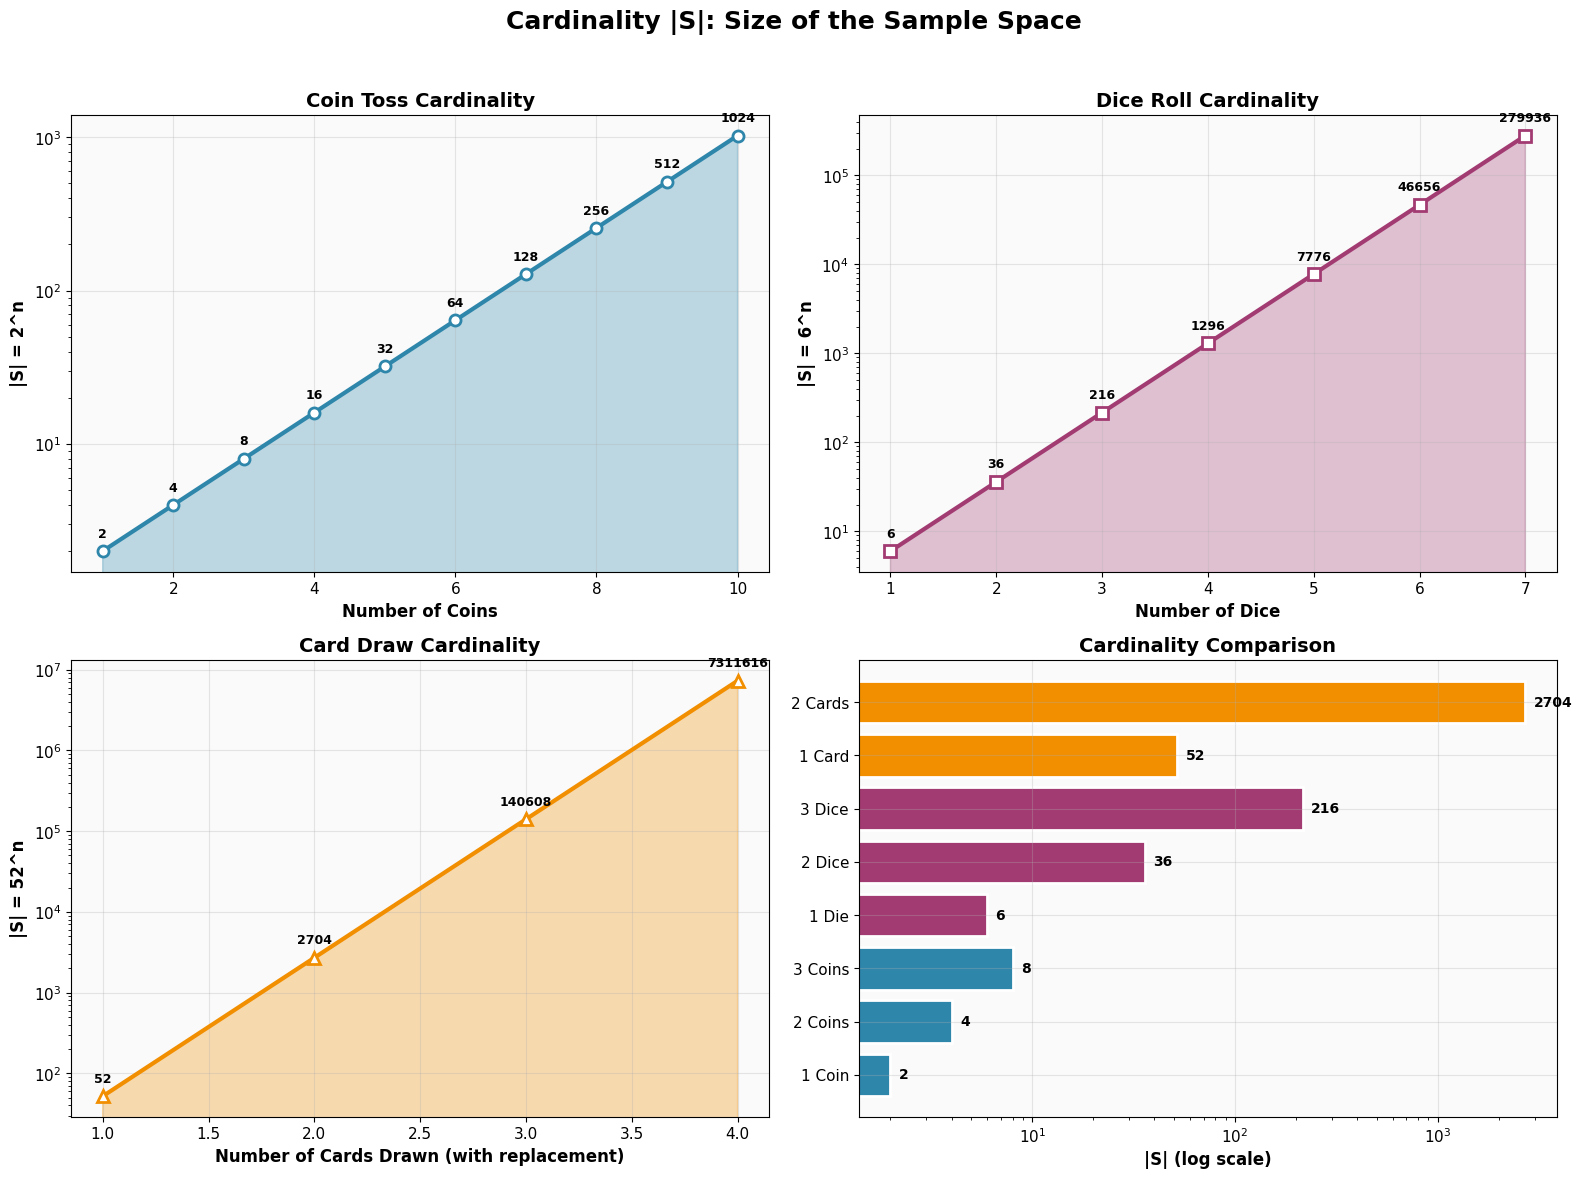

Cardinality Examples:
   1 Coin:  |S| = 2
   3 Coins: |S| = 8
   5 Coins: |S| = 32
   1 Die:   |S| = 6
   2 Dice:  |S| = 36
   1 Card:  |S| = 52
Key Insight: Cardinality grows exponentially with the number of experiments!


In [9]:
# =============================================================================
# SECTION 8: CARDINALITY VISUALIZATION
# =============================================================================

def visualize_cardinality():
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Cardinality |S|: Size of the Sample Space', 
                fontsize=18, fontweight='bold', y=0.98)
    
    # Coin cardinality
    ax1 = axes[0, 0]
    n_coins = range(1, 11)
    coin_sizes = [2**n for n in n_coins]
    ax1.semilogy(n_coins, coin_sizes, 'o-', color=COLORS['primary'], 
                linewidth=3, markersize=8, markerfacecolor='white', markeredgewidth=2)
    ax1.fill_between(n_coins, coin_sizes, alpha=0.3, color=COLORS['primary'])
    ax1.set_xlabel('Number of Coins', fontsize=12, fontweight='bold')
    ax1.set_ylabel('|S| = 2^n', fontsize=12, fontweight='bold')
    ax1.set_title('Coin Toss Cardinality', fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    for n, s in zip(n_coins, coin_sizes):
        ax1.annotate(f'{s}', (n, s), textcoords="offset points", 
                    xytext=(0, 10), ha='center', fontsize=9, fontweight='bold')
    
    # Dice cardinality
    ax2 = axes[0, 1]
    n_dice = range(1, 8)
    dice_sizes = [6**n for n in n_dice]
    ax2.semilogy(n_dice, dice_sizes, 's-', color=COLORS['secondary'], 
                linewidth=3, markersize=8, markerfacecolor='white', markeredgewidth=2)
    ax2.fill_between(n_dice, dice_sizes, alpha=0.3, color=COLORS['secondary'])
    ax2.set_xlabel('Number of Dice', fontsize=12, fontweight='bold')
    ax2.set_ylabel('|S| = 6^n', fontsize=12, fontweight='bold')
    ax2.set_title('Dice Roll Cardinality', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    for n, s in zip(n_dice, dice_sizes):
        ax2.annotate(f'{s}', (n, s), textcoords="offset points", 
                    xytext=(0, 10), ha='center', fontsize=9, fontweight='bold')
    
    # Card cardinality
    ax3 = axes[1, 0]
    n_cards = range(1, 5)
    card_sizes = [52**n for n in n_cards]
    ax3.semilogy(n_cards, card_sizes, '^-', color=COLORS['accent'], 
                linewidth=3, markersize=8, markerfacecolor='white', markeredgewidth=2)
    ax3.fill_between(n_cards, card_sizes, alpha=0.3, color=COLORS['accent'])
    ax3.set_xlabel('Number of Cards Drawn (with replacement)', fontsize=12, fontweight='bold')
    ax3.set_ylabel('|S| = 52^n', fontsize=12, fontweight='bold')
    ax3.set_title('Card Draw Cardinality', fontsize=14, fontweight='bold')
    ax3.grid(True, alpha=0.3)
    for n, s in zip(n_cards, card_sizes):
        ax3.annotate(f'{s}', (n, s), textcoords="offset points", 
                    xytext=(0, 10), ha='center', fontsize=9, fontweight='bold')
    
    # Comparison bar chart
    ax4 = axes[1, 1]
    experiments = ['1 Coin', '2 Coins', '3 Coins', '1 Die', '2 Dice', '3 Dice', '1 Card', '2 Cards']
    sizes = [2, 4, 8, 6, 36, 216, 52, 2704]
    colors = [COLORS['primary']]*3 + [COLORS['secondary']]*3 + [COLORS['accent']]*2
    bars = ax4.barh(experiments, sizes, color=colors, edgecolor='white', linewidth=2)
    ax4.set_xlabel('|S| (log scale)', fontsize=12, fontweight='bold')
    ax4.set_title('Cardinality Comparison', fontsize=14, fontweight='bold')
    ax4.set_xscale('log')
    ax4.grid(True, alpha=0.3, axis='x')
    for bar, size in zip(bars, sizes):
        ax4.text(bar.get_width() * 1.1, bar.get_y() + bar.get_height()/2.,
                f'{size}', va='center', fontsize=10, fontweight='bold')
    
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()
    
    print("Cardinality Examples:")
    print("   1 Coin:  |S| = 2")
    print("   3 Coins: |S| = 8")
    print("   5 Coins: |S| = 32")
    print("   1 Die:   |S| = 6")
    print("   2 Dice:  |S| = 36")
    print("   1 Card:  |S| = 52")
    print("Key Insight: Cardinality grows exponentially with the number of experiments!")

visualize_cardinality()


---

# 9. Counting Principle Animation

## Concept Overview

The **Fundamental Counting Principle** states that if one experiment has $m$ outcomes and another has $n$ outcomes, then together they have $m \times n$ outcomes.

### Mathematical Foundation

$$|S| = m \times n$$

For $k$ independent experiments:

$$|S| = n_1 \times n_2 \times \cdots \times n_k = \prod_{i=1}^{k} n_i$$

### Examples

| Experiment 1 | Experiment 2 | Combined | $|S|$ |
|-------------|-------------|----------|-------|
| Coin (2) | Die (6) | Coin + Die | $2 \times 6 = 12$ |
| Die (6) | Die (6) | Two Dice | $6 \times 6 = 36$ |
| Coin (2) | Coin (2) | Two Coins | $2 \times 2 = 4$ |

### Learning Objective

Understand why sample spaces multiply when combining independent experiments.

### AI Relevance

- **Feature combinations**: $d$ binary features = $2^d$ possible feature vectors
- **Hyperparameter grid**: Cartesian product of all hyperparameter values
- **Multi-modal data**: Combining image + text feature spaces

---

## Counting Principle Visualization


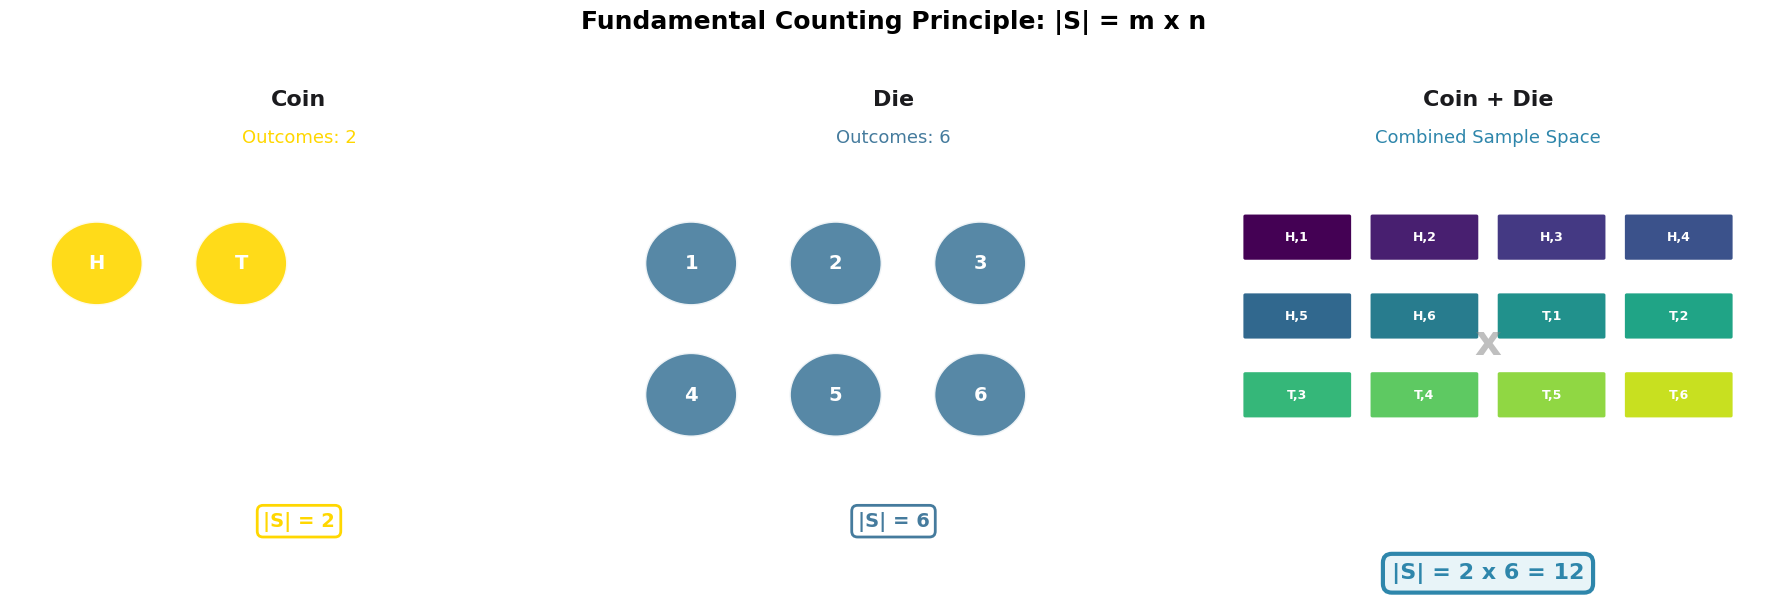

Counting Principle Examples:
   Coin (2) x Die (6) = 12 outcomes
   Die (6) x Die (6) = 36 outcomes
   Coin (2) x Coin (2) x Coin (2) = 8 outcomes
Key Insight: When combining independent experiments, MULTIPLY their sample space sizes!


In [10]:
# =============================================================================
# SECTION 9: COUNTING PRINCIPLE ANIMATION
# =============================================================================

def visualize_counting_principle():
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle('Fundamental Counting Principle: |S| = m x n', 
                fontsize=18, fontweight='bold', y=1.02)
    
    examples = [
        ('Coin', 2, ['H', 'T'], COLORS['coin_heads']),
        ('Die', 6, ['1', '2', '3', '4', '5', '6'], COLORS['die_blue']),
        ('Coin + Die', 12, None, COLORS['primary'])
    ]
    
    for idx, (name, size, labels, color) in enumerate(examples[:2]):
        ax = axes[idx]
        ax.set_xlim(0, 10)
        ax.set_ylim(0, 10)
        ax.axis('off')
        
        ax.text(5, 9.5, name, fontsize=16, fontweight='bold', ha='center', color=COLORS['dark'])
        ax.text(5, 8.8, f'Outcomes: {size}', fontsize=13, ha='center', color=color)
        
        if labels:
            for i, label in enumerate(labels):
                x = 1.5 + (i % 3) * 2.5
                y = 6.5 - (i // 3) * 2.5
                circle = Circle((x, y), 0.8, facecolor=color, edgecolor='white', linewidth=2, alpha=0.9)
                ax.add_patch(circle)
                ax.text(x, y, label, fontsize=14, fontweight='bold', 
                       ha='center', va='center', color='white')
        
        ax.text(5, 1.5, f'|S| = {size}', fontsize=14, fontweight='bold', 
               ha='center', color=color,
               bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=color, linewidth=2))
    
    # Combined
    ax3 = axes[2]
    ax3.set_xlim(0, 10)
    ax3.set_ylim(0, 10)
    ax3.axis('off')
    ax3.text(5, 9.5, 'Coin + Die', fontsize=16, fontweight='bold', ha='center', color=COLORS['dark'])
    ax3.text(5, 8.8, 'Combined Sample Space', fontsize=13, ha='center', color=COLORS['primary'])
    
    outcomes = [(c, d) for c in ['H', 'T'] for d in ['1', '2', '3', '4', '5', '6']]
    for i, (c, d) in enumerate(outcomes):
        x = 0.8 + (i % 4) * 2.2
        y = 7 - (i // 4) * 1.5
        rect = FancyBboxPatch((x, y - 0.4), 1.8, 0.8,
                               boxstyle="round,pad=0.05",
                               facecolor=plt.cm.viridis(i/12), 
                               edgecolor='white', linewidth=1.5)
        ax3.add_patch(rect)
        ax3.text(x + 0.9, y, f'{c},{d}', fontsize=9, fontweight='bold',
                ha='center', va='center', color='white')
    
    ax3.text(5, 0.5, '|S| = 2 x 6 = 12', fontsize=16, fontweight='bold', 
            ha='center', color=COLORS['primary'],
            bbox=dict(boxstyle='round,pad=0.4', facecolor='#E8F4F8', 
                     edgecolor=COLORS['primary'], linewidth=3))
    
    # Multiplication symbol
    ax3.text(5, 5, 'x', fontsize=30, fontweight='bold', 
            ha='center', va='center', color='gray', alpha=0.5)
    
    plt.tight_layout()
    plt.show()
    
    print("Counting Principle Examples:")
    print("   Coin (2) x Die (6) = 12 outcomes")
    print("   Die (6) x Die (6) = 36 outcomes")
    print("   Coin (2) x Coin (2) x Coin (2) = 8 outcomes")
    print("Key Insight: When combining independent experiments, MULTIPLY their sample space sizes!")

visualize_counting_principle()
